<a href="https://colab.research.google.com/github/mAliAytekin/ai-research-notes/blob/main/Deep_Kronecker_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kronecker çarpımı & Matrix

- kronecker çarpımı, 2 matrisin blok şeklindeki çarpımıdır
- A⊗B şeklinde gösterilir
- her bir A elemanı a<sub>ij</sub> , B ile çarpılarak bir blok oluşturur
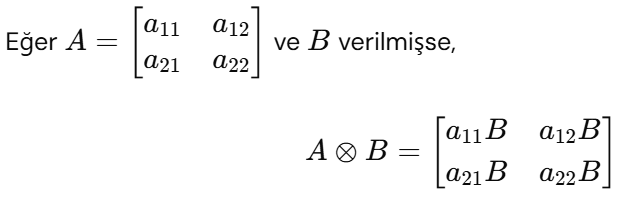

### Normal matris çarpımlarından farkı ve dezavantaj/avantajları

- standart çarpımda A sütun sayısı = B satır sayısı olmalıdır
- standar çarpım, satır-sütun iç çarpımlarına dayanır, kronecker ise blok yerleştirmesine dayalıdır
- lineer denklem sistemlerini vektör formuna taşır
- kronecker çarpımları büyük matrisler üretir
- NN'de parametre sayısını azaltabilir
- uzay-kanal-zaman ayrışması gereken durumlarda bu model kullanılabilir, bu ayrıştırma modelin anlamasını ve genelleştirmesini iyileştirebilir
- kronecker matrix çarpımları daha hızlıdır
- veri A⊗B olarak ifade ediliyorsa, A ve B ayrı ayrı saklanabilir, bu da bizi daha az parametre kullanmaya götürür
- parametre sayısı azaldığından overfitting sorunu azalabilir
- ama uygulamayı karmaşık hale getirme ihtimali de var. burada iki farklı matrise ayrışabilme kritiktir. esnekliği ve performansı olumsuz etkileyebilir bu durum
- yani verinin doğal bir şekilde (örneğin uzay x kanal x zaman) şeklinde ayrışabilmesi önemlidir

### Neural Network açısından düşünürsek

- büyük bir W matrisini doğrudan öğrenmek yerine, onu 2 ya da daha fazla küçük matrisin kronecker çarpımı olarak temsil edebiliriz
- W = A ⊗ B olsun..
- W 1024x1024 boyutunda olsaydı 1048576 parametre içerirdi..
- W' yi 32x32 boyunda A ve B matrislerinin Kronecker çarpımı olarak ifade edersek, NN'nin öğrenmesi gereken parametre sayısı sadece A ve B'nin elemanları olur...
- 32x32 + 32x32 = 2048.. ciddi bir parametre tasarrufu demektir bu



### iris veri seti ile örnek

- Öğrenilecek küçük matrisler: A (q1 x p1) ve B (q2 x p2)
- W (q1 * q2 x p1 * p2) matrisini oluşturacaklar.  
- forward aşamasında:
  - girdi(x), A ⊗ B ile çarpılır
  - bu aşamada boyutlar küçük olduğundan hızlıdır.
  - (B X A^T)^T formülü kullanılır

In [37]:
!pip install torchinfo

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from torchinfo import summary



In [39]:
class KroneckerLinear(nn.Module):

  def __init__(self,in_features,out_features,in_factors,out_factors):
    super().__init__()
    p1,p2 = in_factors
    q1,q2 = out_factors

    if p1 * p2 != in_features:
        raise ValueError(f"Girdi faktörleri {in_factors} toplam girdi boyutu {in_features} ile uyumsuz.")
    if q1 * q2 != out_features:
        raise ValueError(f"Çıktı faktörleri {out_factors} toplam çıktı boyutu {out_features} ile uyumsuz.")

    self.in_features = in_features
    self.out_features = out_features
    self.in_factors = in_factors
    self.out_factors = out_factors

    self.A = nn.Parameter(torch.randn(q1, p1))
    self.B = nn.Parameter(torch.randn(q2, p2))

    self.bias = nn.Parameter(torch.randn(out_features))

    nn.init.kaiming_uniform_(self.A, a=torch.math.sqrt(5))
    nn.init.kaiming_uniform_(self.B, a=torch.math.sqrt(5))

  def forward(self, x):
    p1,p2 = self.in_factors
    x_reshaped = x.view(-1, p1,p1)
    result = self.A @ x_reshaped.transpose(1,2)
    result = self.A @ result.transpose(1,2)
    output = result.transpose(1,2).reshape(-1,self.out_features)
    output = output + self.bias
    return output

  def __repr__(self):
      return (f"KroneckerLinear(in_features={self.in_features}, out_features={self.out_features}, "
              f"in_factors={self.in_factors}, out_factors={self.out_factors})")


In [40]:
class DeepKronecker(nn.Module):

  def __init__(self,input_size,hidden_size,output_size):
    super().__init__()
    self.kron_layer1 = KroneckerLinear(
        in_features=input_size,
        out_features=hidden_size,
        in_factors=(2,2),
        out_factors=(4,4)
    )
    self.act = nn.ReLU()

    self.out = nn.Linear(hidden_size,output_size)


  def forward(self,x):
    x = self.kron_layer1(x)
    x = self.act(x)
    x = self.out(x)
    return x

In [41]:
def get_iris_data(test_size=0.2):
  iris = load_iris()
  X,y = iris.data, iris.target

  X_train, X_test, y_train, y_test  = train_test_split(X,y,test_size=test_size,random_state=42,stratify=y)

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  train_dataset = TensorDataset(torch.tensor(X_train,dtype=torch.float32),torch.tensor(y_train,dtype=torch.long))
  test_dataset = TensorDataset(torch.tensor(X_test,dtype=torch.float32),torch.tensor(y_test,dtype=torch.long))

  return train_dataset, test_dataset


In [42]:
def train_and_test_model(model,device):
  BATCH_SIZE = 8
  LEARNING_RATE = 0.005
  EPOCHS = 50
  train_dataset, test_dataset = get_iris_data()
  train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
  test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

  params = sum(p.numel() for p in model.parameters())
  print(f"\nParametre Sayısı: {params}")

  for epoch in range(1,EPOCHS+1):
    model.train()
    for data,target in train_loader:
      data,target = data.to(device), target.to(device)
      optimizer.zero_grad()
      output = model(data)
      loss = criterion(output,target)
      loss.backward()
      optimizer.step()

    if epoch % 5 == 0:
      model.eval()
      correct = 0
      total = 0
      with torch.no_grad():
        for data,target in test_loader:
          data,target = data.to(device),target.to(device)
          output = model(data)
          _,predicted = torch.max(output.data,1)
          total += target.size(0)
          correct += (predicted == target).sum().item()
      accuracy = 100 * correct / total
      print(f'Epoch {epoch}/{EPOCHS}, Test Başarısı: {accuracy:.2f}%')


In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepKronecker(input_size=4,hidden_size=16,output_size=3).to(device)
train_and_test_model(model,device)
print(summary(model))


Parametre Sayısı: 83
Epoch 5/50, Test Başarısı: 80.00%
Epoch 10/50, Test Başarısı: 90.00%
Epoch 15/50, Test Başarısı: 93.33%
Epoch 20/50, Test Başarısı: 93.33%
Epoch 25/50, Test Başarısı: 93.33%
Epoch 30/50, Test Başarısı: 93.33%
Epoch 35/50, Test Başarısı: 96.67%
Epoch 40/50, Test Başarısı: 93.33%
Epoch 45/50, Test Başarısı: 96.67%
Epoch 50/50, Test Başarısı: 96.67%
Layer (type:depth-idx)                   Param #
DeepKronecker                            --
├─KroneckerLinear: 1-1                   32
├─ReLU: 1-2                              --
├─Linear: 1-3                            51
Total params: 83
Trainable params: 83
Non-trainable params: 0


### standart MLP

In [44]:
class StandardMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # Tam bağlantılı, yoğun (dense) katmanlar
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.activation = nn.ReLU()
        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x

In [45]:
model = StandardMLP(input_size=4, hidden_size=16, output_size=3)
train_and_test_model(model,device)
print(summary(model))




Parametre Sayısı: 131
Epoch 5/50, Test Başarısı: 80.00%
Epoch 10/50, Test Başarısı: 90.00%
Epoch 15/50, Test Başarısı: 93.33%
Epoch 20/50, Test Başarısı: 96.67%
Epoch 25/50, Test Başarısı: 96.67%
Epoch 30/50, Test Başarısı: 93.33%
Epoch 35/50, Test Başarısı: 96.67%
Epoch 40/50, Test Başarısı: 96.67%
Epoch 45/50, Test Başarısı: 96.67%
Epoch 50/50, Test Başarısı: 96.67%
Layer (type:depth-idx)                   Param #
StandardMLP                              --
├─Linear: 1-1                            80
├─ReLU: 1-2                              --
├─Linear: 1-3                            51
Total params: 131
Trainable params: 131
Non-trainable params: 0


### resources

- https://hakanateslii.medium.com/kronecker-product-kronecker-%C3%A7arp%C4%B1m%C4%B1-d71dec9fed4b

- coding with Gemini 2.5 pro
